1. Setup e Importações

Nesta célula, preparamos o ambiente instalando e importando as bibliotecas necessárias para manipulação de grafos (networkx), visualização (matplotlib) e análise de dados (pandas, json).

In [30]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import json
import os
import scipy
from pyvis.network import Network

In [31]:
# Função para capturar os pratos nas chaves padronizadas
def extrair_por_macro_categoria(json_data, macro):
    cardapio = json_data.get("cardapio_completo", {})
    mapeamento = {
        'Entradas': ['entradas_e_petiscos'],
        'Pratos Principais': ['pratos_principais'],
        'Saladas': ['saladas'],
        'Sobremesas': ['sobremesas']
    }
    
    lista_final = []
    chaves = mapeamento.get(macro, [])
    for c in chaves:
        lista_final.extend(cardapio.get(c, []))
    return lista_final

def calcular_jaccard(g, u, v):
    if u not in g or v not in g: return 0
    viz_u, viz_v = set(g.neighbors(u)), set(g.neighbors(v))
    inter = len(viz_u.intersection(viz_v))
    uniao = len(viz_u.union(viz_v))
    return inter / uniao if uniao > 0 else 0

# Carregamento dos arquivos revisados
with open("../data/processados/ner_camaroes.json", "r", encoding="utf-8") as f: raw_cam = json.load(f)
with open("../data/processados/ner_cocobambu.json", "r", encoding="utf-8") as f: raw_cb = json.load(f)

2. Função de Similaridade e Plotagem

Utilizaremos o Índice de Jaccard para calcular a proximidade entre os pratos com base nos ingredientes.

In [ ]:
def plotar_analise_final(macro_nome):
    lista_cam = extrair_por_macro_categoria(raw_cam, macro_nome)
    lista_cb = extrair_por_macro_categoria(raw_cb, macro_nome)
    
    G = nx.Graph()
    # Povoamento Bipartido
    for rest, lista, cor in [("Camarões", lista_cam, "skyblue"), ("Coco Bambu", lista_cb, "orange")]:
        for item in lista:
            id_p = f"({rest}) {item['nome']}"
            G.add_node(id_p, type='PRATO', restaurant=rest, color=cor, label=item['nome'])
            for ing in item.get('ingredientes', []):
                ing_node = ing.lower().strip()
                G.add_node(ing_node, type='ING', color='lightgray')
                G.add_edge(id_p, ing_node)

    # Filtragem de nós isolados para clareza visual
    S = G.subgraph([n for n, d in G.degree() if d > 1 or G.nodes[n].get('type')=='PRATO']).copy()
    
    plt.figure(figsize=(16, 10))
    pos = nx.spring_layout(S, k=0.5, iterations=50)
    
    # Estilização das arestas baseada na conectividade
    widths = []
    for u, v in S.edges():
        # Verifica se o nó 'u' é o ingrediente ou se o nó 'v' é o ingrediente
        is_hub_u = S.nodes[u].get('type') == 'ING' and S.degree(u) > 2
        is_hub_v = S.nodes[v].get('type') == 'ING' and S.degree(v) > 2
        
        if is_hub_u or is_hub_v:
            widths.append(2.8) # Aresta grossa para conexões importantes
        else:
            widths.append(0.5) # Aresta fina para o restante
            
    nx.draw(S, pos, labels={n: S.nodes[n].get('label', n) for n in S.nodes()},
            with_labels=True, node_color=[S.nodes[n].get('color', 'lightgray') for n in S.nodes()],
            node_size=[1200 if S.nodes[n].get('type')=='PRATO' else 250 for n in S.nodes()],
            font_size=8, width=widths, edge_color='silver', alpha=0.8)

    plt.title(f"Similaridade Gastronômica: {macro_nome} (Camarões vs CocoBanbu)", fontsize=16)
    cam_patch = mpatches.Patch(color='skyblue', label='Camarões (Natal)')
    cb_patch = mpatches.Patch(color='orange', label='Coco Bambu (Fortaleza)')
    plt.legend(handles=[cam_patch, cb_patch], loc='upper right')
    # Salva a imagem na pasta imagens
    file_name = f"similaridade_{macro_nome.lower().replace(" ", "_")}.png"
    plt.savefig(f"../data/imagens/{file_name}", dpi=300, bbox_inches="tight")
    plt.show()
    

    # Relatório de Pares Espelhados
    pc, pb = [n for n, d in S.nodes(data=True) if d.get('restaurant')=='Camarões'], [n for n, d in S.nodes(data=True) if d.get('restaurant')=='Coco Bambu']
    print(f"\n Top Similares em {macro_nome}:")
    matches = sorted([(p1, p2, calcular_jaccard(S, p1, p2)) for p1 in pc for p2 in pb], key=lambda x: x[2], reverse=True)
    for p1, p2, s in matches[:5]:
        if s > 0.3: print(f" {s:.1%} | {p1} <-> {p2}")

    return G

4. Execução por Bloco

Execute cada categoria separadamente para gerar os três grafos:

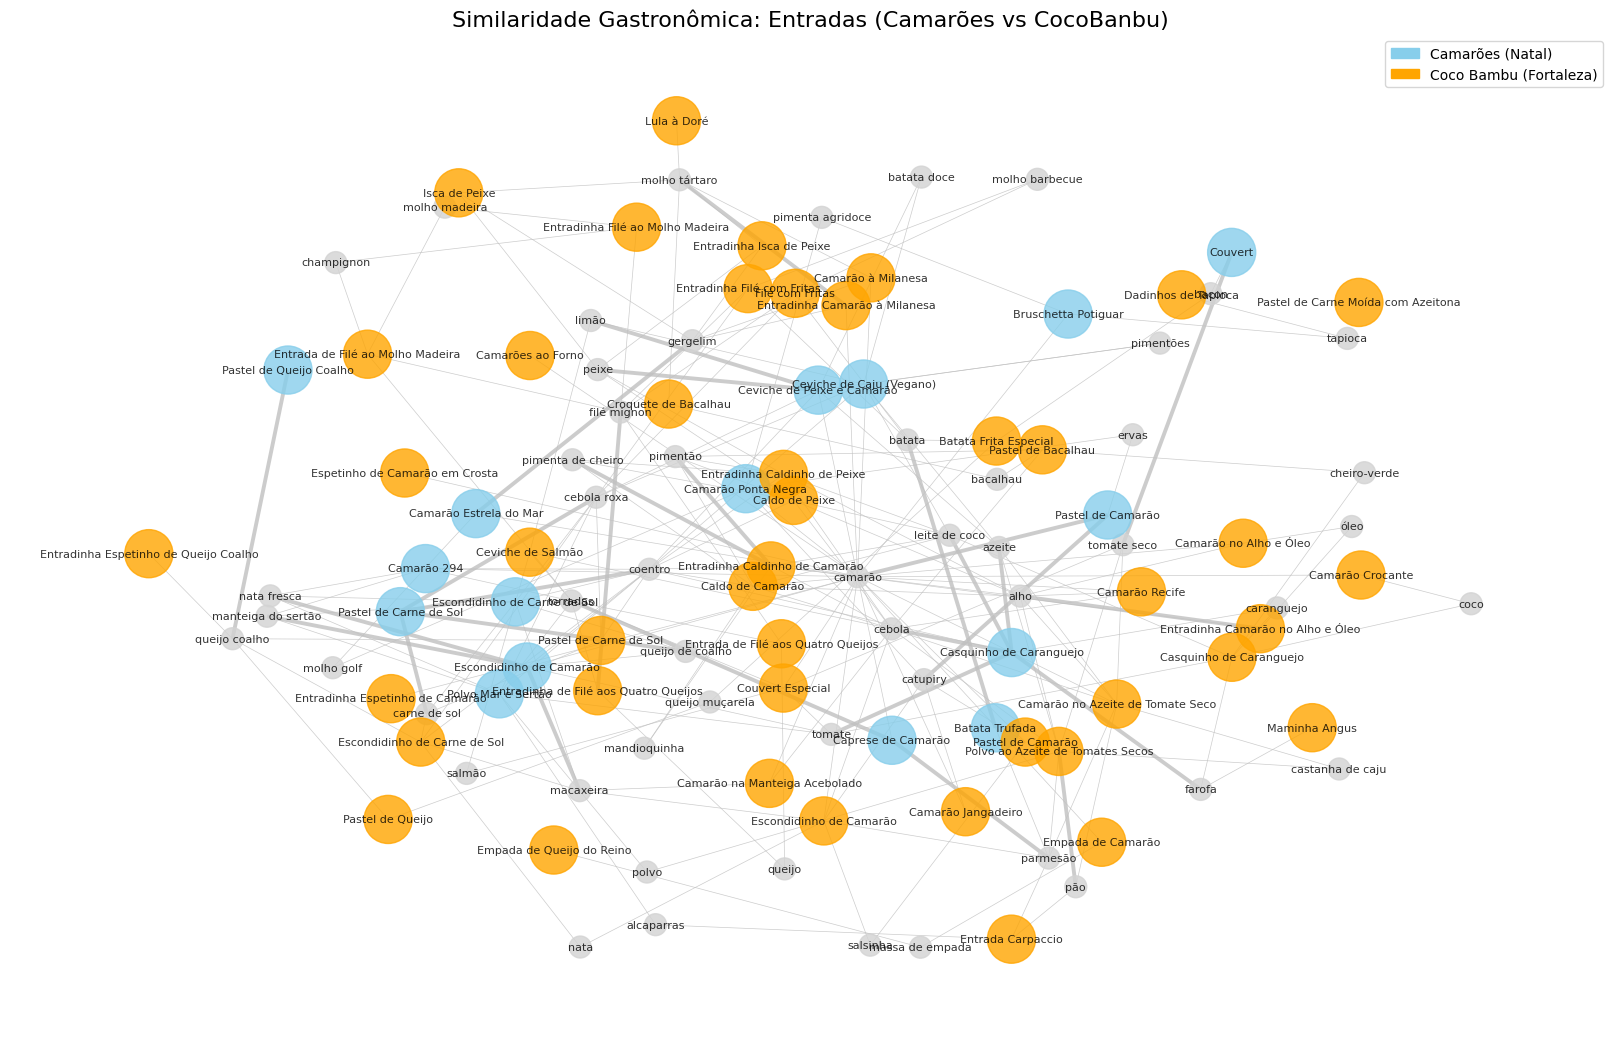


 Top Similares em Entradas:
 100.0% | (Camarões) Pastel de Queijo Coalho <-> (Coco Bambu) Entradinha Espetinho de Queijo Coalho
 66.7% | (Camarões) Pastel de Camarão <-> (Coco Bambu) Camarão Jangadeiro
 60.0% | (Camarões) Pastel de Carne de Sol <-> (Coco Bambu) Pastel de Carne de Sol
 50.0% | (Camarões) Pastel de Camarão <-> (Coco Bambu) Pastel de Camarão
 50.0% | (Camarões) Pastel de Queijo Coalho <-> (Coco Bambu) Pastel de Queijo


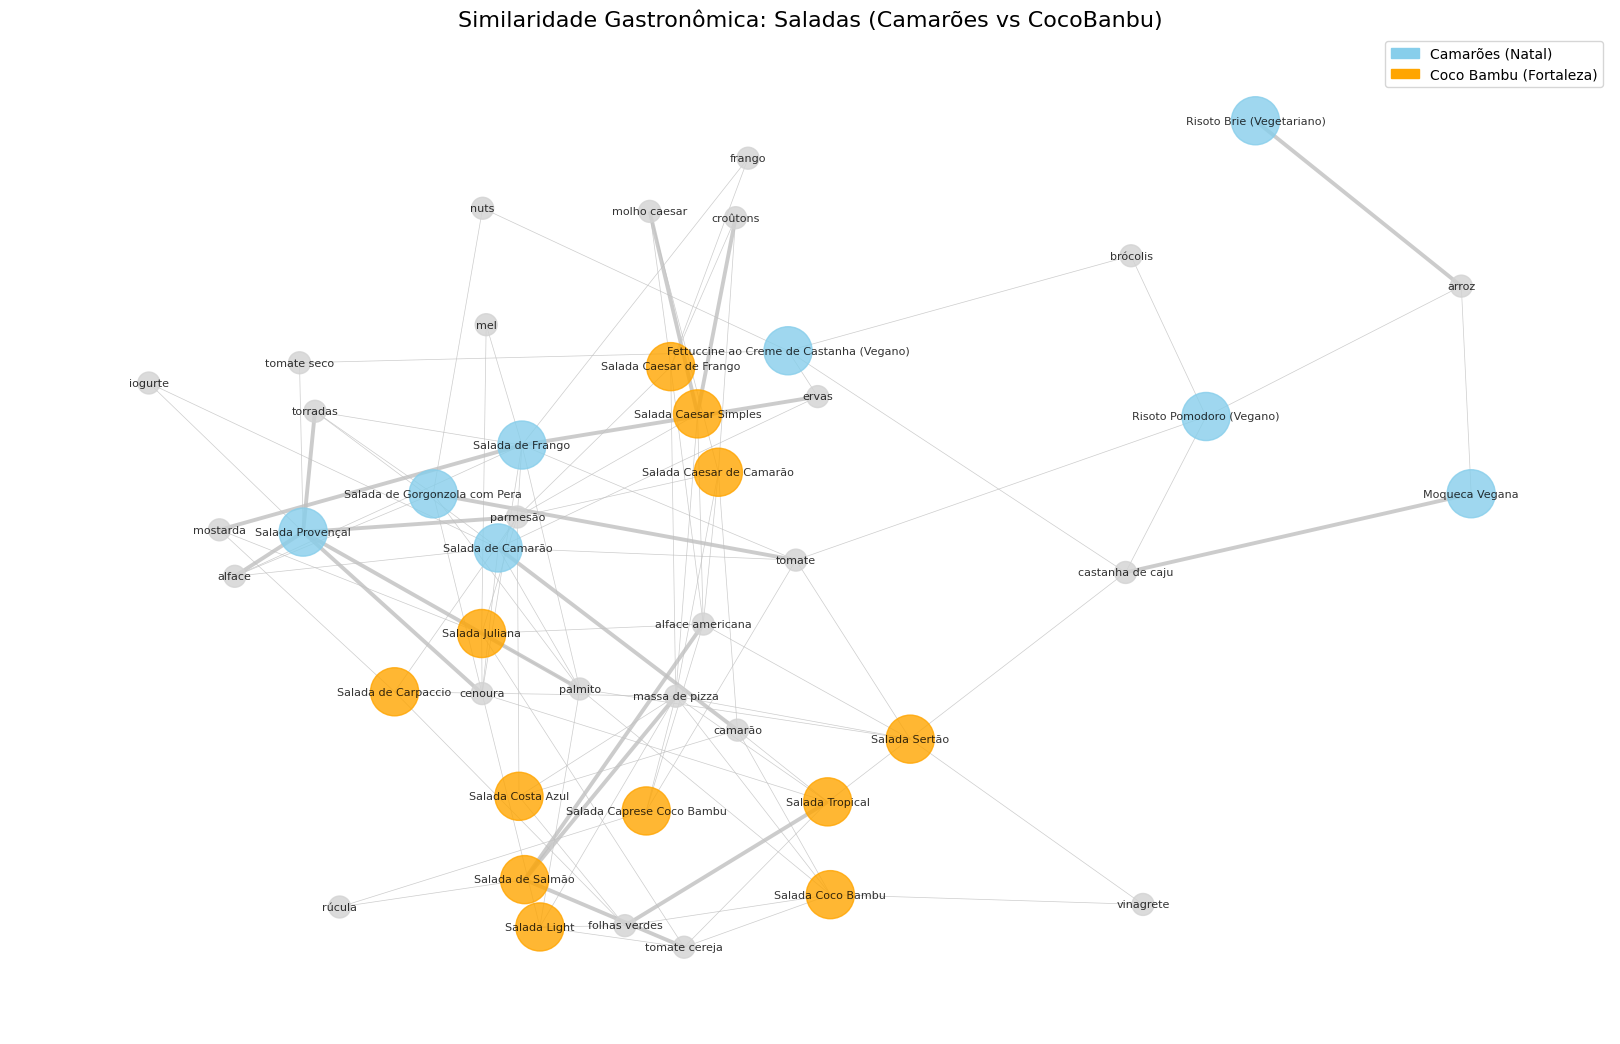


 Top Similares em Saladas:
 41.7% | (Camarões) Salada de Frango <-> (Coco Bambu) Salada Juliana


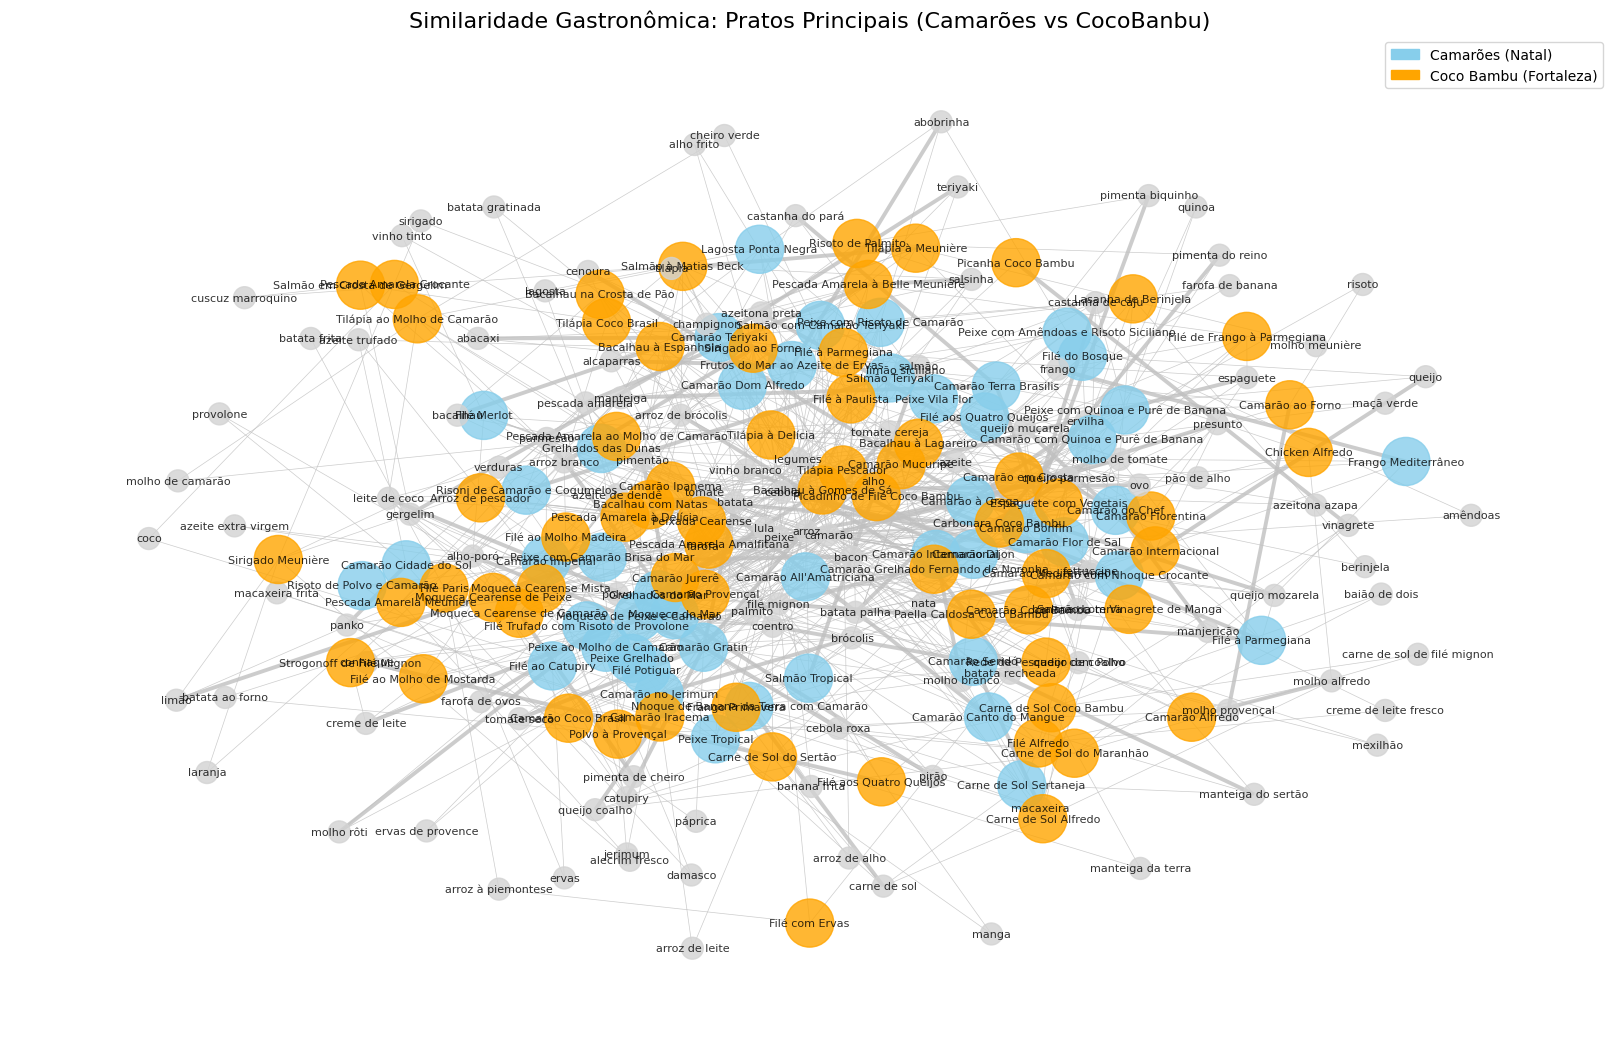


 Top Similares em Pratos Principais:
 77.8% | (Camarões) Camarão Internacional <-> (Coco Bambu) Camarão Internacional
 70.0% | (Camarões) Camarão Internacional <-> (Coco Bambu) Camarão Coco Bambu
 66.7% | (Camarões) Moqueca de Peixe e Camarão <-> (Coco Bambu) Moqueca Cearense Mista
 58.3% | (Camarões) Moqueca de Peixe e Camarão <-> (Coco Bambu) Moqueca Cearense de Camarão
 58.3% | (Camarões) Moqueca de Peixe e Camarão <-> (Coco Bambu) Moqueca Cearense de Peixe


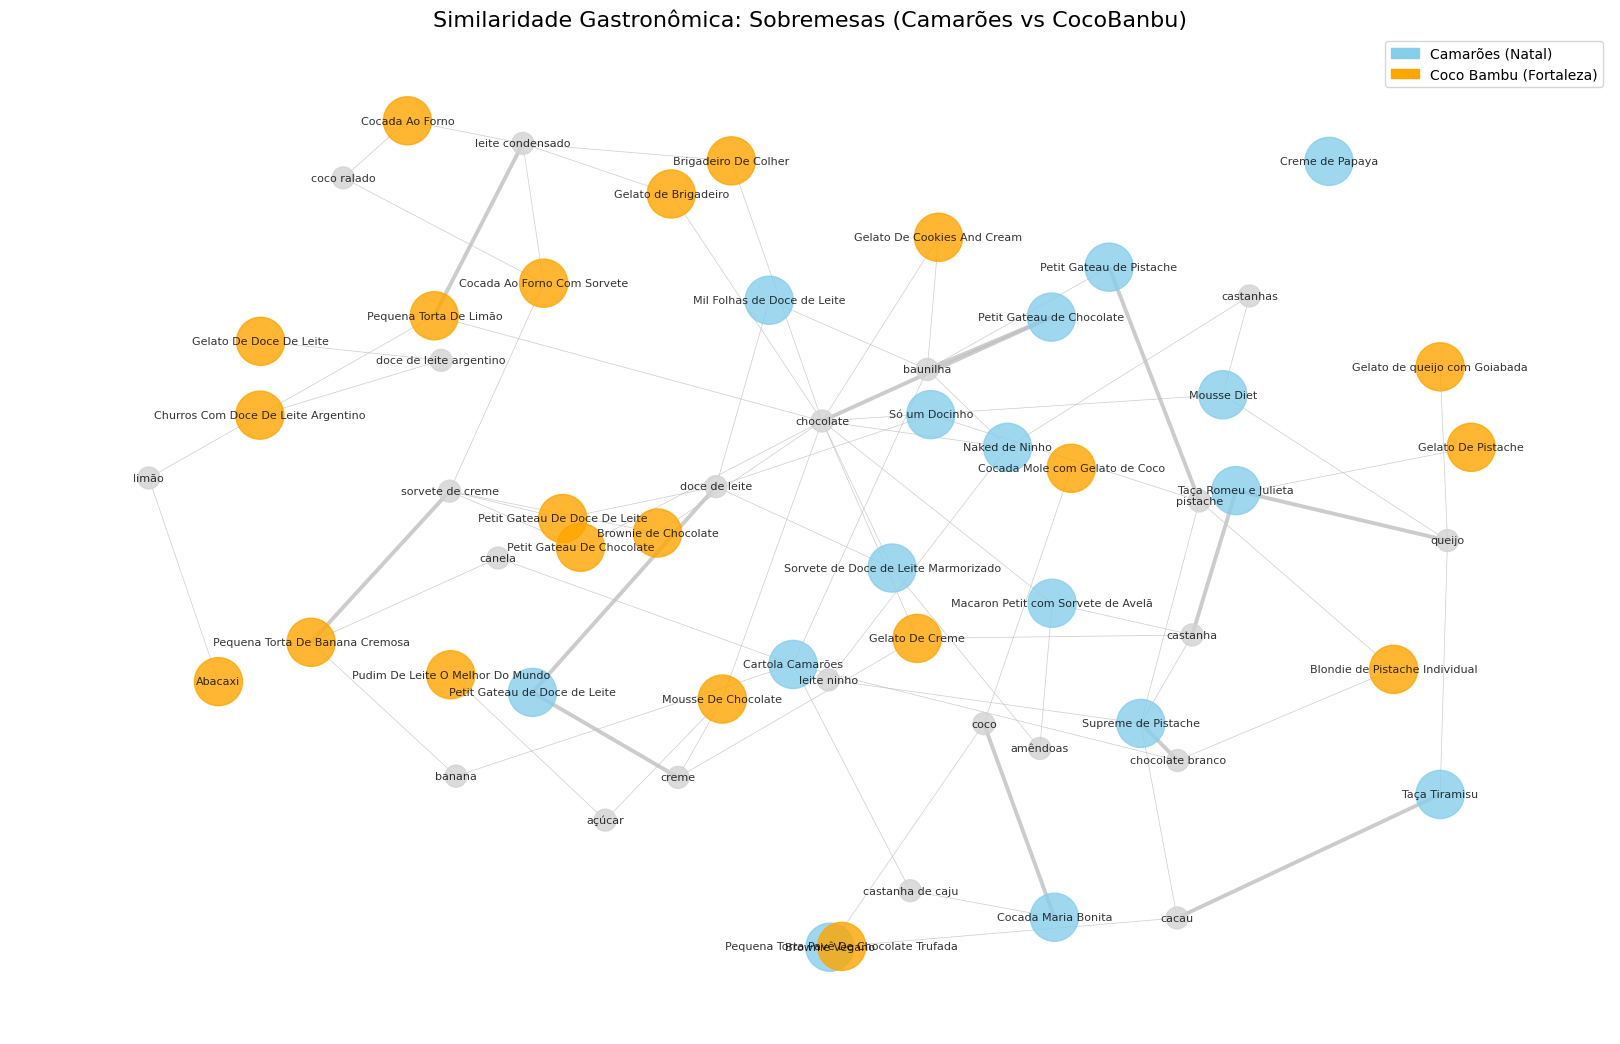


 Top Similares em Sobremesas:
 100.0% | (Camarões) Petit Gateau de Chocolate <-> (Coco Bambu) Gelato De Cookies And Cream
 50.0% | (Camarões) Petit Gateau de Pistache <-> (Coco Bambu) Gelato De Pistache
 50.0% | (Camarões) Taça Romeu e Julieta <-> (Coco Bambu) Gelato de queijo com Goiabada
 50.0% | (Camarões) Taça Tiramisu <-> (Coco Bambu) Gelato de queijo com Goiabada
 50.0% | (Camarões) Naked de Ninho <-> (Coco Bambu) Gelato De Cookies And Cream


In [42]:
# 1. Entradas
E = plotar_analise_final('Entradas')

# 2. Saladas (Agora como categoria exclusiva)
S = plotar_analise_final('Saladas')

# 3. Pratos Principais
P = plotar_analise_final('Pratos Principais')

# 4. Sobremesas
SM = plotar_analise_final('Sobremesas')

6. Extração da Matriz de Adjacência

Conversão da estrutura topológica do grafo em uma representação algébrica. Esta matriz de adjacência é exportada para CSV, permitindo auditorias e usos em outros modelos matemáticos.

In [43]:
import pandas as pd
import networkx as nx
import os

# 1. Mapeamento das variáveis para nomes de arquivos
subgrafos = {
    "Entradas": E,
    "Pratos_Principais": P,
    "Saladas": S,
    "Sobremesas": SM
}

# 2. Caminho da pasta de saída
output_dir = "../data/matriz_adj/"
os.makedirs(output_dir, exist_ok=True)

print("📊 --- Gerando Matrizes de Adjacência por Categoria ---")

for nome, grafo in subgrafos.items():
    # Verifica se a variável existe e não está vazia
    if grafo is not None and len(grafo.nodes()) > 0:
        # Garante a ordem dos nós para a matriz
        nodelist = list(grafo.nodes())
        
        # Gera a matriz de adjacência (formato array)
        A = nx.adjacency_matrix(grafo, nodelist=nodelist).toarray()
        
        # Cria o DataFrame com rótulos
        df_adj = pd.DataFrame(A, index=nodelist, columns=nodelist)
        
        # Salva o arquivo CSV correspondente
        file_name = f"matriz_adj_{nome.lower()}.csv"
        file_path = os.path.join(output_dir, file_name)
        df_adj.to_csv(file_path)
        
        print(f"✅ {nome}: Salva em {file_name} | Dimensões: {df_adj.shape}")
    else:
        print(f"⚠️ {nome}: Grafo vazio ou variável não definida.")

print("\n📍 Todos os arquivos estão disponíveis em: data/matriz_adj/")

📊 --- Gerando Matrizes de Adjacência por Categoria ---
✅ Entradas: Salva em matriz_adj_entradas.csv | Dimensões: (153, 153)
✅ Pratos_Principais: Salva em matriz_adj_pratos_principais.csv | Dimensões: (311, 311)
✅ Saladas: Salva em matriz_adj_saladas.csv | Dimensões: (83, 83)
✅ Sobremesas: Salva em matriz_adj_sobremesas.csv | Dimensões: (94, 94)

📍 Todos os arquivos estão disponíveis em: data/matriz_adj/
